In [68]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import os

from src.constants import EARLY_NTCP_TIMEPOINTS
def determine_CITOR_model_name(endpoint_name):
    endpoint_name = endpoint_name.lower()

    toxicity_name = "_".join(endpoint_name.split("_")[:-1])
    if toxicity_name == 'sticky':
        toxicity_name = 'sticky_saliva'

    timepoint = endpoint_name.split("_")[-1]

    CITOR_name = toxicity_name
    if timepoint in EARLY_NTCP_TIMEPOINTS:
        CITOR_name += "_early"
    else:
        CITOR_name += "_late"

    return CITOR_name



def refit_CITOR_model(config, df_train, endpoint = "Xerostomia_M06", CITOR_model_name = 'xerostomia_late'):
    
    if len(config['CITOR'][CITOR_model_name]['models'].keys()) > 1:
        feature_dict = {'model1':{}, 'model2':{}}
        submodel_names = ['model1', 'model2']

        #all_feature_columns = list(set()) 
    else:
        feature_dict = {'model1':{}}
        submodel_names = ['model1']   


    # refit (all of the sub-) models
    for submodel_names in submodel_names:
        # select the columns per submodel
        feature_column_names = np.array(config['CITOR'][CITOR_model_name]['models'][submodel_names]['features'])

        X_train = df_train[feature_column_names]
        y_train = df_train[endpoint]

        # make and fit the (sub)model
        sub_model = LogisticRegression(random_state=config['general']['seed'], C=1e10, max_iter = 1000)

        # Messy things to handle any missing data
        valid_indices = y_train != -1
        X_train = X_train[valid_indices]
        y_train = y_train[valid_indices]
        
        # fit the model
        sub_model.fit(X_train, y_train)

        # save the submodel in the feature_dict
        feature_dict[submodel_names]['features'] = feature_column_names
        feature_dict[submodel_names]['coef'] = sub_model.coef_[0]
        feature_dict[submodel_names]['intercept'] = sub_model.intercept_[0]

        # print(f"submodel {submodel_names} has been fitted")
        # sub_model_dict = {f: c for f, c in zip(feature_column_names, sub_model.coef_[0])}
        # print(sub_model_dict)
        # print(feature_dict[submodel_names]['intercept'])


    # combine the submodels
    if len(feature_dict.keys()) > 1:
        model1 = list(feature_dict.keys())[0]
        model2 = list(feature_dict.keys())[1]
        features = []
        coef = []
        features.append('intercept')
        coef.append(.5*(feature_dict[model1]['intercept'] + feature_dict[model2]['intercept']))
        
        features1 = feature_dict[model1]['features']
        features2 = feature_dict[model2]['features']
        
        overlap =  list(set(features1) & set(features2))
        remainder_m1 = list(set(features1) - set(features2))
        remainder_m2 = list(set(features2) - set(features1))

        
        for i in range(len(remainder_m1)):
            features.append(remainder_m1[i])
            coef.append(.5*(feature_dict[model1]['coef'][np.where(features1 == remainder_m1[i])])[0])         
        for i in range(len(remainder_m2)):
            features.append(remainder_m2[i])
            coef.append(.5*(feature_dict[model2]['coef'][np.where(features2 == remainder_m2[i])])[0])    
        for i in range(len(overlap)):
            features.append(overlap[i])
            coef.append(.5*(feature_dict[model1]['coef'][np.where(features1 == overlap[i])]+feature_dict[model2]['coef'][np.where(features2 == overlap[i])])[0])     
   
    else:
        features = ['intercept'] + list(feature_column_names)
        coef =[sub_model.intercept_[0]] + list(sub_model.coef_[0]) 


    # print(features)
    # features_coeff_dict = {k: v for k, v in zip(features, coef)}
    # print(features_coeff_dict)
    # print(coef[1:])
    
    model = LogisticRegression(random_state=config['general']['seed'], C=1e10, max_iter = 1000, multi_class='ovr')
    model.intercept_ = np.array([coef[0]])
    model.coef_ = np.array([coef[1:]])

    return model, features[1:] 


PATIENT_ID_COL_NAME = "PatientID"

def run_logistic_regression_posthoc(config, df_features, train_val_patient_IDs, test_patient_IDs, endpoint_list = ["Xerostomia_M06"]):
    # get the train and val patients' data
    df_train_val = df_features[df_features[PATIENT_ID_COL_NAME].isin(train_val_patient_IDs)]

    # get the test patients' data (if you want that)
    df_test = df_features[df_features[PATIENT_ID_COL_NAME].isin(test_patient_IDs)]

    test_aucs_dict = {}
    

    for idx, endpoint in enumerate(endpoint_list):
        #print(f"fitting models for {endpoint}")
        CITOR_model_name = determine_CITOR_model_name(endpoint)
        #print(CITOR_model_name)

        model, feature_column_names = refit_CITOR_model(config, df_train_val, endpoint = endpoint, CITOR_model_name = CITOR_model_name)

        df_train_val_X = df_train_val.loc[:, feature_column_names].values

        train_val_preds = model.predict_proba(df_train_val_X)[:,1]

        df_test_X = df_test.loc[:, feature_column_names].values
        test_preds = model.predict_proba(df_test_X)[:,1]


        # compute the AUC
        #print(test_preds)
        #print(len(df_test_X), len(test_preds), len(df_test[endpoint]))

        indicies = np.where(df_test[endpoint] != -1)[0]

        y_pred = test_preds[indicies]
        y_true = df_test[endpoint].values[indicies]
        #print(y_pred)

        auc = roc_auc_score(y_true, y_pred)

        test_aucs_dict[endpoint] = round(auc, 23)

    return test_aucs_dict


In [109]:
from src.config_presets.tools.get_config import get_config
config = get_config('Trial32_Config')

src\config_presets\Base_config.yaml
src\config_presets\Trial32_Config.yaml


In [110]:

splits_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\PRI2MA\HNC_complete_dataset_excel\test_split_seeds"

split_files = os.listdir(splits_dir)

endpoint_list = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06"]
#split_files.sort()

all_test_aucs_dict = []

for rand_seed in range(1000):
    #print(filename)
    rand_seed = str(rand_seed).zfill(3)
    df = pd.read_csv(os.path.join(splits_dir, f"train_val_test_split_{rand_seed}.csv"))

    df_train_val = df[df['Split'] == 'train_val']
    df_test = df[df['Split'] == 'test']
    train_val_patient_IDs = df_train_val['PatientID'].values
    test_patient_IDs = df_test['PatientID'].values

    test_aucs_dict = run_logistic_regression_posthoc(config, df, train_val_patient_IDs, test_patient_IDs, endpoint_list = endpoint_list)
    test_aucs_dict['seed'] = rand_seed  # int(filename.split('.')[0].split('_')[-1])
    all_test_aucs_dict.append(test_aucs_dict)

In [115]:
df_test_aucs = pd.DataFrame(all_test_aucs_dict)
df_test_aucs.set_index('seed', inplace=True)

In [116]:
test_aucs_dict

{'Aspiration_M06': 0.6873496873496873,
 'Dysphagia_M06': 0.8405119869971556,
 'Sticky_M06': 0.7378130891462429,
 'Taste_M06': 0.7040998217468805,
 'Xerostomia_M06': 0.7560034838870224,
 'seed': '999'}

In [117]:
# Assuming df_test_aucs is your DataFrame
column_means = df_test_aucs.mean(axis=0)

# Print the means
print(column_means)

Aspiration_M06    0.736079
Dysphagia_M06     0.817050
Sticky_M06        0.694829
Taste_M06         0.711529
Xerostomia_M06    0.745540
dtype: float64


In [ ]:
# Calculate the mean of each column
column_means = df_test_aucs.mean(axis=0)

# Calculate the mean distance for each row across all columns
df_test_aucs['mean_distance'] = df_test_aucs.apply(lambda row: abs((row - column_means)).sum(), axis=1)

# Sort the rows by the mean distance and select the top 10 rows
top_10_nearest = df_test_aucs.nsmallest(10, 'mean_distance')

# Drop the temporary 'mean_distance' column if no longer needed
df_test_aucs.drop(columns=['mean_distance'], inplace=True)

# Print the top 10 rows
print(top_10_nearest)

      Aspiration_M06  Dysphagia_M06  Sticky_M06  Taste_M06  Xerostomia_M06  \
seed                                                                         
936         0.737893       0.812568    0.677676   0.707942        0.753083   
500         0.733653       0.818970    0.709121   0.707330        0.759221   
762         0.741251       0.822495    0.694978   0.728338        0.754781   
034         0.731328       0.820056    0.711731   0.714915        0.736019   
773         0.708965       0.815426    0.694531   0.712040        0.737156   
665         0.748271       0.813018    0.682489   0.712871        0.736629   
950         0.735496       0.823965    0.677827   0.696350        0.744360   
829         0.719774       0.801270    0.699650   0.709251        0.749809   
236         0.736396       0.849615    0.684990   0.709786        0.745566   
900         0.724786       0.822554    0.715635   0.714488        0.749482   

      mean_distance  
seed                 
936        0.069158

In [114]:
# Calculate the mean of each column
column_means = df_test_aucs.mean(axis=0)

# Calculate the mean distance for each row across all columns
df_test_aucs['mean_distance'] = df_test_aucs.apply(lambda row: abs((row - column_means)**3).mean(), axis=1)

# Sort the rows by the mean distance and select the top 10 rows
top_10_nearest = df_test_aucs.nsmallest(10, 'mean_distance')

# Drop the temporary 'mean_distance' column if no longer needed
df_test_aucs.drop(columns=['mean_distance'], inplace=True)

# Print the top 10 rows
print(top_10_nearest)

      Aspiration_M06  Dysphagia_M06  Sticky_M06  Taste_M06  Xerostomia_M06  \
seed                                                                         
665         0.748271       0.813018    0.682489   0.712871        0.736629   
500         0.733653       0.818970    0.709121   0.707330        0.759221   
936         0.737893       0.812568    0.677676   0.707942        0.753083   
762         0.741251       0.822495    0.694978   0.728338        0.754781   
034         0.731328       0.820056    0.711731   0.714915        0.736019   
067         0.745845       0.825411    0.682079   0.708671        0.761383   
915         0.733569       0.825688    0.691205   0.724603        0.728818   
230         0.745628       0.816684    0.710965   0.719697        0.759337   
829         0.719774       0.801270    0.699650   0.709251        0.749809   
734         0.718585       0.819395    0.704918   0.700207        0.754435   

      mean_distance  
seed                 
665    8.933174e-07

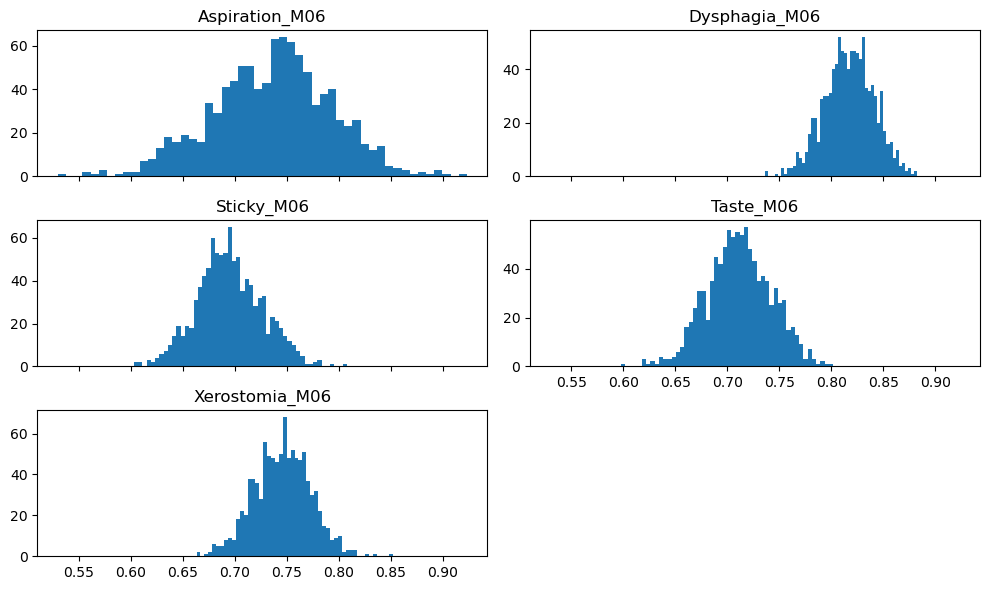

In [119]:
# Plot histograms for all columns
df_test_aucs.hist(figsize=(10, 6), grid=False, bins=50, sharex=True)

import matplotlib.pyplot as plt
# Show the plot
plt.tight_layout()
plt.show()